# Loading libraries

In [1]:
#pip install gldpy

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time
from itertools import combinations

from scipy.stats import shapiro, ttest_ind, mannwhitneyu, chi2_contingency, kruskal, f_oneway, levene, spearmanr, normaltest, norm

# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA
# from sklearn.experimental import enable_iterative_imputer  # required to enable
# from sklearn.impute import IterativeImputer

from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm
import statsmodels.formula.api as smf

from gldpy import GLD

# Functions to analyse metadata



## Assessing data distribution

In [2]:
gld = GLD('FMKL')

def analyze_distribution_by_label(df, column, bins_hist = 20, label_col='Label', test_gof=False):
    """
    Visualize and test normality (Shapiro-Wilk) for a specific column grouped by label.

    Parameters:
    - df: DataFrame containing the data
    - column: str, name of the column to analyze
    - label_col: str, name of the label column to group by (default: 'Label')
    """
    labels = df[label_col].dropna().unique()

    print(f"\n=== Analyzing '{column}' by '{label_col}' ===\n")

    for label in labels:
        # subset = df[df[label_col] == label][column].dropna()
        # subset = subset[np.isfinite(subset)]
        subset = df.loc[df[label_col] == label, column]
        subset = pd.to_numeric(subset, errors='coerce')
        subset = subset.replace([np.inf, -np.inf], np.nan).dropna()
        print("n:", len(subset), "finite:", np.isfinite(subset).sum())
        print("min/max:", subset.min(), subset.max())
        print(f"\nLabel: {label} — Variable: {column}")
        print(f"Sample size: {len(subset)}")

        if len(subset) < 3:
            print("Not enough data for visual or Shapiro-Wilk test.")
            continue

        gld.fit_MM(subset.values, [1, 1], bins_hist = bins_hist, maxiter=1000, maxfun=1000, test_gof=test_gof )

        # Shapiro-Wilk test
        stat, p = shapiro(subset)
        print(f"Shapiro-Wilk test: W={stat:.4f}, p-value={p:.4f}")
        if p > 0.05:
            print("Probably Gaussian (normal distribution)")
        else:
            print("Probably NOT Gaussian")
        # time.sleep(5)


## Chi square

The Chi-squared test with the full $n$×2 table checks if any difference exists somewhere in the $n$ groups.

If this test is not significant, no need for pairwise tests.

If this test is significant, you know that some groups differ, but not which ones.

Chi square maths:

$O_{ij}$: observed value in row $i$, column $j$

$E_{ij}$: expected value in row $i$, column $j$


$H_0$: Sex and Label are independent. That is, the distribution of Sex is the same across all Labels.


$$E_{ij}=\frac{(Row \ total_i) \ x \ (Col \ Total_i)}{Grand \ total}$$

Being $Gran \ total$ the total number of observations.

Finally, $\chi^2$ is calculated as:


$$\chi^2 =\sum_i\sum_j\frac{O_{ij} - E_{ij}}{E_{ij}}$$

In [3]:
def chi_squared_vs_label(df, binary_col='Sex', label_col='Label'):
    """
    Perform chi-squared test of independence between a binary col and Label.

    Parameters:
    - df: DataFrame with columns for sex and label
    - binary_col: column name for binary variable (0/1)
    - label_col: column name for labels

    Returns:
    - Prints test result and contingency table
    """
    # Drop missing
    df_clean = df[[binary_col, label_col]].dropna()

    # Convert to int (if float like 0.0, 1.0)
    df_clean[binary_col] = df_clean[binary_col].astype(int)

    # Contingency table
    contingency = pd.crosstab(df_clean[label_col], df_clean[binary_col])
    contingency.columns = ['Male (0)', 'Female (1)']

    print("\nContingency Table (Label × Sex):\n")
    print(contingency)

    # Chi-squared test
    chi2, p, dof, expected = chi2_contingency(contingency)
    print("\nChi-squared Test Results:")
    print(f"Chi2 statistic = {chi2:.4f}")
    print(f"Degrees of freedom = {dof}")
    print(f"p-value = {p:.4f}\n")

    if p < 0.05:
        print("Significant association between Sex and Label")
    else:
        print("No significant association between Sex and Label")

    return contingency


## Assessing significant differences between groups

- [Kruskal Wallis](https://datatab.net/tutorial/kruskal-wallis-test)
- ANOVA

In [4]:
def test_by_label(df, column, label_col='Label', test='kruskal'):
    """
    Perform Kruskal-Wallis or ANOVA test to compare distributions across labels,
    and check assumptions for ANOVA (homoscedasticity and residuals).
    
    Parameters:
    - df: pandas DataFrame
    - column: str, numeric variable to compare
    - label_col: str, group label column (default 'Label')
    - test: str, 'kruskal' (default) or 'anova' to specify which test to perform
    """
    
    grouped = df[[label_col, column]].dropna().groupby(label_col)[column]
    data = [group for _, group in grouped]  # Extract column data per group
    labels = list(grouped.groups.keys())
    
    if len(data) < 2:
        print(f"Need at least 2 groups for {test} test.")
        return

    if test == 'kruskal':
        stat, p = kruskal(*data)
        test_name = "Kruskal-Wallis"
        print(f"\n{test_name} test for '{column}' across labels {labels}:")
        print(f"Test statistic: {stat:.4f}")
        print(f"p-value: {p:.4f}")
        if p < 0.05:
            print("Significant differences found between groups.")
        else:
            print("No significant differences between groups.")
    
    elif test == 'anova':
        formula = f'{column} ~ C({label_col})'
        model = sm.formula.ols(formula, data=df).fit()
        anova_results = sm.stats.anova_lm(model, typ=2)

        print(f"\nANOVA Table for '{column}' across labels {labels}:")
        print(anova_results)

        # Levene's test for homogeneity of variances
        lev_stat, lev_p = levene(*data)
        print("\nLevene's test for equal variances:")
        print(f"Levene statistic: {lev_stat:.4f}")
        print(f"p-value: {lev_p:.4f}")
        if lev_p < 0.05:
            print("Warning: Variances are significantly different (heteroscedasticity).")
        else:
            print("Variances are approximately equal (homoscedasticity).")

        # Residual analysis
        print("\nResidual analysis for ANOVA assumptions:")
        residuals = model.resid
        fitted = model.fittedvalues

        # Plot residuals
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        sns.histplot(residuals, kde=True, ax=axes[0])
        axes[0].set_title("Histogram of Residuals")
        axes[0].set_xlabel("Residuals")

        sm.qqplot(residuals, line='s', ax=axes[1])
        axes[1].set_title("Q-Q Plot of Residuals")

        plt.tight_layout()
        plt.show()


    else:
        raise ValueError("Invalid test specified. Choose 'kruskal' or 'anova'.")

- Mannwhitney
- [t-test](https://datatab.net/tutorial/t-test)

In [5]:
from itertools import combinations
from scipy.stats import mannwhitneyu, ttest_ind, levene
from statsmodels.stats.multitest import multipletests
import pandas as pd
import numpy as np

def cohen_d(group1, group2):
    """Compute Cohen's d for two independent samples."""
    diff = group1.mean() - group2.mean()
    n1, n2 = len(group1), len(group2)
    pooled_std = np.sqrt(((n1 - 1) * group1.std(ddof=1) ** 2 + (n2 - 1) * group2.std(ddof=1) ** 2) / (n1 + n2 - 2)) # doff: Delta Degrees of Freedom
    return diff / pooled_std if pooled_std != 0 else np.nan

def rank_biserial(group1, group2):
    """Compute rank biserial correlation (effect size for Mann-Whitney U)."""
    u_stat, _ = mannwhitneyu(group1, group2, alternative='two-sided')
    n1, n2 = len(group1), len(group2)
    return 1 - (2 * u_stat) / (n1 * n2)

def pairwise_test(df, label_col, column, test='mannwhitney', correction='bonferroni'):
    """
    Perform pairwise statistical tests between groups defined by label_col.

    Parameters:
    - df: pandas DataFrame
    - label_col: str, column with group labels
    - column: str, numeric variable to test
    - test: str, 'mannwhitney' (default) or 'ttest' to choose the test
    - correction: str, method for multiple testing correction (default 'bonferroni')

    Returns:
    - DataFrame with pairwise test statistics, raw and adjusted p-values,
      Levene's test p-value, and effect size.
    """

    df_clean = df[[label_col, column]].dropna()
    labels = df_clean[label_col].unique()
    pairs = list(combinations(labels, 2))

    results = []

    for a, b in pairs:
        group_a = df_clean[df_clean[label_col] == a][column]
        group_b = df_clean[df_clean[label_col] == b][column]

        stat_name = None
        stat = p = levene_p = effect_size = None

        if len(group_a) >= 3 and len(group_b) >= 3:
            # Levene's test for variance homogeneity
            _, levene_p = levene(group_a, group_b)

            if test == 'mannwhitney':
                stat, p = mannwhitneyu(group_a, group_b, alternative='two-sided')
                stat_name = 'U'
                effect_size = rank_biserial(group_a, group_b)
            elif test == 'ttest':
                if levene_p < 0.05:
                    # If variances are unequal, use Welch's t-test
                    stat, p = ttest_ind(group_a, group_b, equal_var=False)
                else:
                    stat, p = ttest_ind(group_a, group_b, equal_var=True) 
                stat_name = 't'
                effect_size = cohen_d(group_a, group_b)
            else:
                raise ValueError("Invalid test specified. Choose 'mannwhitney' or 'ttest'.")

        results.append({
            'Group1': a,
            'Group2': b,
            stat_name: stat,
            'p_raw': p,
            'p_levene': levene_p,
            'effect_size': effect_size
        })

    results_df = pd.DataFrame(results)

    valid_methods = ['bonferroni', 'holm', 'fdr_bh', 'fdr_by', 'sidak', 'holm-sidak', 'hommel']
    if correction not in valid_methods:
        raise ValueError(f"Unsupported correction method: {correction}")

    pvals = results_df['p_raw'].fillna(1.0).values
    _, p_adjusted, _, _ = multipletests(pvals, method=correction)
    results_df['p_adjusted'] = p_adjusted.clip(max=1.0)

    return results_df


# Loading metadata

In [7]:
# Load the dataframe
df = pd.read_csv(r"C:\Users\Marcos\Documents\IDIVAL\Proyectos\Audio_Parkinson\Audio_HUMV_enhanced\HUMV_enhanced_metadata.csv", sep = ',')  # or already in memory
#df = pd.read_csv(r"C:\Users\Marcos\Documents\IDIVAL\Proyectos\Audio_Parkinson\joined_metadata_HUMV_IPV.csv", sep = ';')
df.head()

,ID,Sex,Age,Label,UPDRS_III_2024,H&Y_2024,Years_education
0,HUMV_HC_1,1,67,0,0.0,0.0,15.0
1,HUMV_HC_2,1,65,0,1.0,0.0,17.0
2,HUMV_HC_3,1,69,0,NaN,NaN,NaN
3,HUMV_HC_4,1,39,0,0.0,0.0,8.0
4,HUMV_HC_5,1,67,0,1.0,0.0,10.0


In [8]:
df.dtypes

ID                  object
Sex                  int64
Age                  int64
Label                int64
UPDRS_III_2024     float64
H&Y_2024           float64
Years_education    float64
dtype: object

# Analysis metadata of four groups (HC, NFC, AC, PD)

## Checking distribution of data

### Age


=== Analyzing 'Age' by 'Label' ===

n: 26 finite: 26
min/max: 39 83

Label: 0 — Variable: Age
Sample size: 26
Optimization terminated successfully.
         Current function value: 0.000007
         Iterations: 133
         Function evaluations: 248

Sample moments:  (np.float64(69.65384615384616), np.float64(81.30325443786981), np.float64(-1.274713693365663), np.float64(5.823449689487913))
Fitted moments:  (np.float64(69.65384615384616), np.float64(81.30325443786981), np.float64(-1.2747101569890238), np.float64(5.823456902324611))

Parameters:  [np.float64(72.13274119258), np.float64(0.15957641150605584), np.float64(-0.032440918042329056), np.float64(0.5675075931093245)]
Shapiro-Wilk test: W=0.8952, p-value=0.0122
Probably NOT Gaussian
n: 24 finite: 24
min/max: 45 88

Label: 1 — Variable: Age
Sample size: 24
Optimization terminated successfully.
         Current function value: 0.000026
         Iterations: 68
         Function evaluations: 126

Sample moments:  (np.float64(64.208333

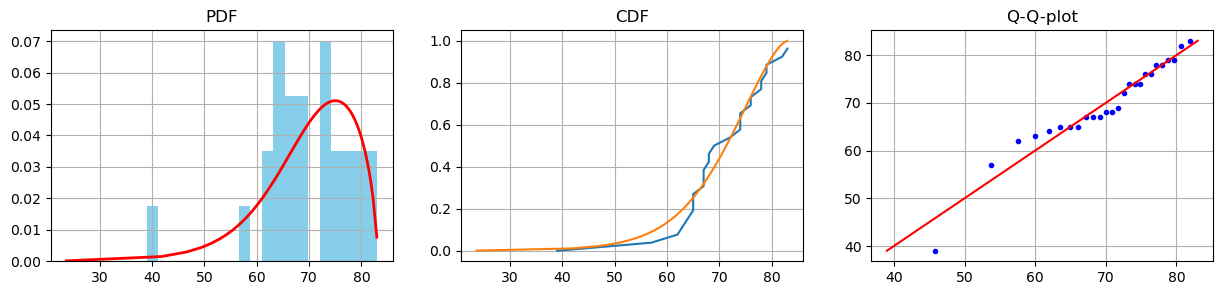

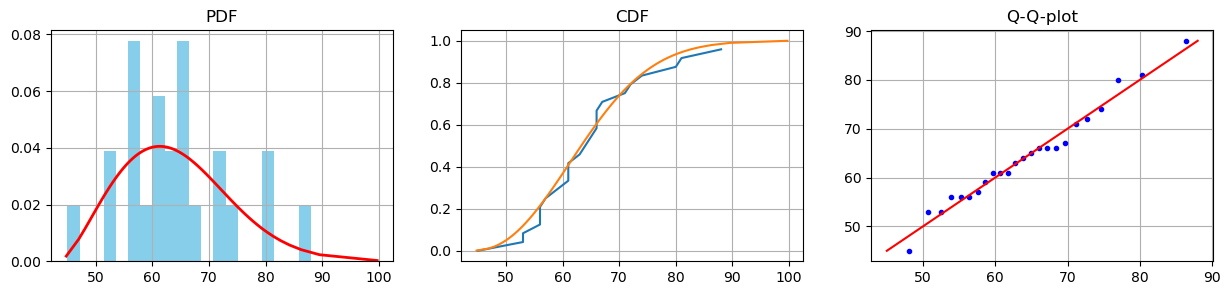

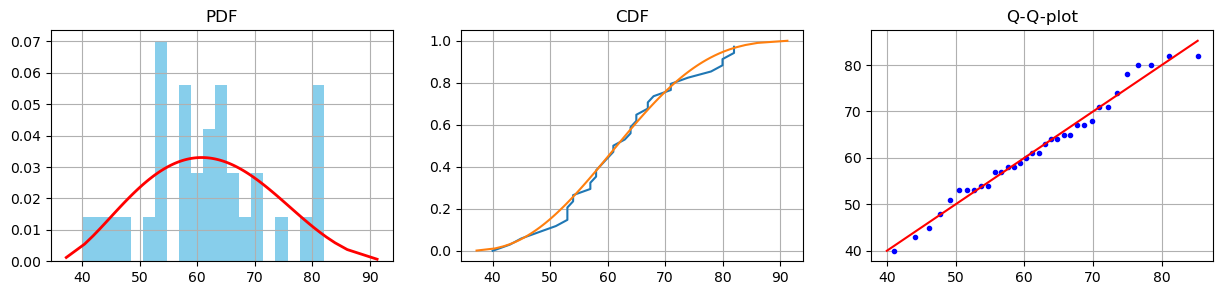

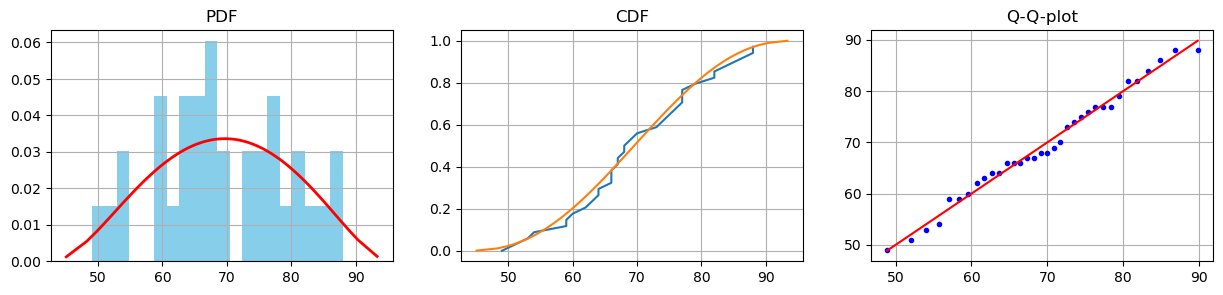

In [8]:
# Example usage:
analyze_distribution_by_label(df, column='Age')

### Years education


=== Analyzing 'Years_education' by 'Label' ===

n: 25 finite: 25
min/max: 5.0 21.0

Label: 0 — Variable: Years_education
Sample size: 25
Optimization terminated successfully.
         Current function value: 0.000012
         Iterations: 57
         Function evaluations: 101

Sample moments:  (np.float64(12.2), np.float64(17.68), np.float64(0.38611709525482524), np.float64(2.1640117933703245))
Fitted moments:  (np.float64(12.2), np.float64(17.68), np.float64(0.38612775734653265), np.float64(2.1640239274643513))

Parameters:  [np.float64(11.213480044329732), np.float64(0.18934831873455404), np.float64(0.9717347021067442), np.float64(0.4409979423371639)]
Shapiro-Wilk test: W=0.9382, p-value=0.1348
Probably Gaussian (normal distribution)
n: 24 finite: 24
min/max: 8.0 22.0

Label: 1 — Variable: Years_education
Sample size: 24
Optimization terminated successfully.
         Current function value: 0.241077
         Iterations: 71
         Function evaluations: 131

Sample moments:  (np.floa

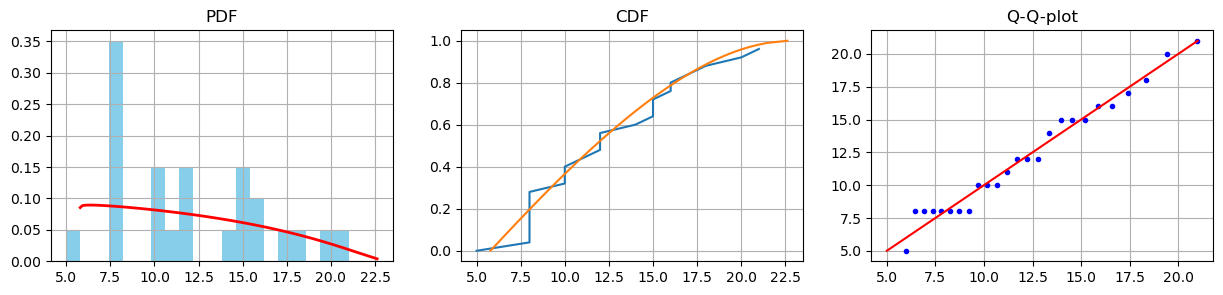

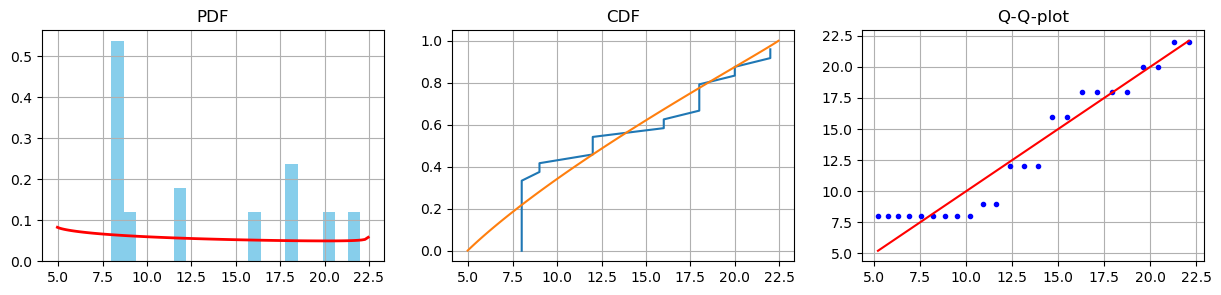

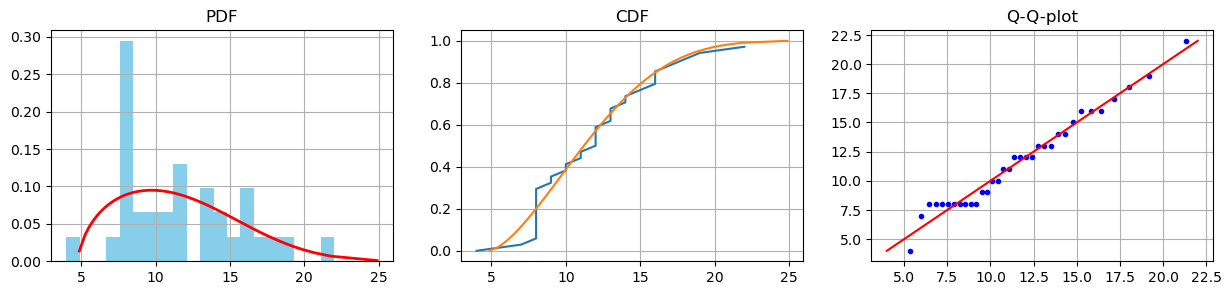

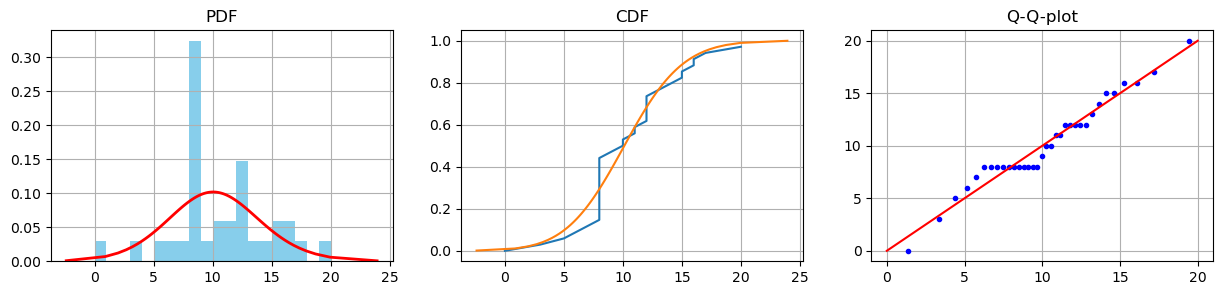

In [9]:
analyze_distribution_by_label(df, column='Years_education')

## Age


ANOVA Table for 'Age' across labels [0, 1, 2, 3]:
                sum_sq     df         F    PR(>F)
C(Label)   1391.545885    3.0  4.388195  0.005819
Residual  12050.225302  114.0       NaN       NaN

Levene's test for equal variances:
Levene statistic: 0.5781
p-value: 0.6305
Variances are approximately equal (homoscedasticity).

Residual analysis for ANOVA assumptions:


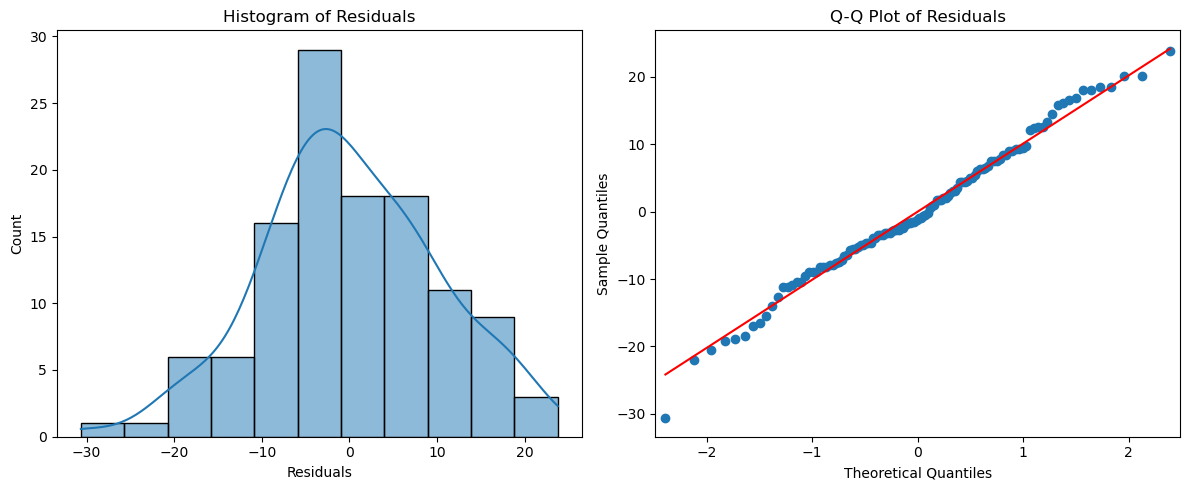

In [10]:
test_by_label(df, column='Age', label_col='Label', test='anova')

In [11]:
result = pairwise_test(df, label_col = 'Label', column='Age',  test='ttest', correction='bonferroni')
print(result)

   Group1  Group2         t     p_raw  p_levene  effect_size  p_adjusted
0       0       1  2.017124  0.049294  0.714484     0.570986    0.295764
1       0       2  2.873612  0.005662  0.248038     0.748648    0.033974
2       0       3  0.059276  0.952936  0.317197     0.015443    1.000000
3       1       2  0.802137  0.425864  0.456275     0.213854    1.000000
4       1       3 -1.934620  0.058095  0.561028    -0.515780    0.348568
5       2       3 -2.888326  0.005233  0.837106    -0.700522    0.031398


### Years of education

In [39]:
test_by_label(df, column='Years_education', label_col='Label', test='kruskal')

KeyError: "['Years_education'] not in index"

## Results

In the initial exploratory analysis, we examined whether there were statistically significant differences in sex, age, and years of education across the different label groups (4: HC, NFC, AC, PD).

- Significant differences in age were observed between label groups 0 and 2, as well as between groups 2 and 3.

- No significant differences were found for sex or years of education across the label groups.

       count       mean        std   min    25%   50%    75%   max
Label                                                             
0       26.0  69.653846   9.195400  39.0  65.00  68.5  76.00  83.0
1       24.0  64.208333   9.895010  45.0  56.75  63.5  68.00  88.0
2       34.0  61.941176  11.067126  40.0  54.00  61.0  67.75  82.0
3       34.0  69.500000  10.506131  49.0  63.25  68.0  77.00  88.0


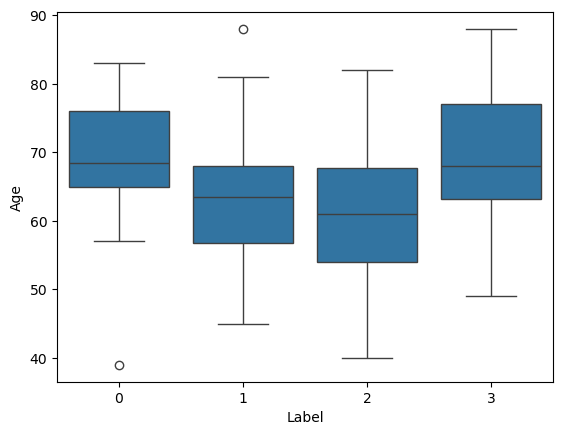

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Summary stats
print(df.groupby('Label')['Age'].describe())

# Boxplot
sns.boxplot(data=df, x='Label', y='Age')
plt.show()


In [25]:
def detect_outliers_iqr(df, group_col, target_col):
    outliers = []
    for label, group in df.groupby(group_col):
        Q1 = group[target_col].quantile(0.25)
        Q3 = group[target_col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        group_outliers = group[(group[target_col] < lower_bound) | (group[target_col] > upper_bound)]
        outliers.append(group_outliers)
    return pd.concat(outliers)

outliers_df = detect_outliers_iqr(df, 'Label', 'Age')
print(outliers_df[['ID', 'Label', 'Age']])


             ID  Label   Age
49    HUMV_HC_4      0  39.0
95  HUMV_NFC_24      0  45.0
22     IPV_PD_5      2  40.0


In [26]:
# Example: remove oldest patients from label with highest mean age
label_means = df.groupby('Label')['Age'].mean()
label_to_trim = label_means.idxmax()
print(f"Removing oldest patients from label {label_to_trim}")

# Define how many to remove (e.g., top 2 oldest)
to_remove = df[df['Label'] == label_to_trim].nlargest(2, 'Age')['ID']
print("Patients to remove:", to_remove.tolist())

df_balanced = df[~df['ID'].isin(to_remove)]


Removing oldest patients from label 2
Patients to remove: ['HUMV_PD_1', 'HUMV_PD_2']


Given these age differences, we decided to remove specific patients with ages that contribute to this imbalance in order to homogenize the groups for subsequent analyses.

The following patients will be removed:

- HUMV_HC_4: Age = 39
- HUMV_HC_9: Age = 82
- HUMV_HC_25: Age = 83
- HUMV_NFC_1: Age = 81
- HUMV_NFC_11: Age = 88
- HUMV_NFC_24: Age = 45
- HUMV_AC_24: Age = 48 (with DaTSCAN)
- HUMV_AC_32: Age = 45 (with DaTSCAN)
- HUMV_PD_1: Age = 88
- HUMV_PD_2: Age = 88
- HUMV_PD_13: Age = 86

All other patients without DaTScan

In [49]:
# List of patient IDs to remove
patients_to_remove = ['HUMV_HC_4', 'HUMV_HC_9', 'HUMV_HC_25', 'HUMV_NFC_1', 'HUMV_NFC_11', 'HUMV_NFC_24' ,'HUMV_PD_1', 'HUMV_PD_2', 'HUMV_PD_9', 'HUMV_PD_13', 'HUMV_AC_2','HUMV_AC_5', 'HUMV_AC_7','HUMV_AC_8','HUMV_AC_13','HUMV_AC_14','HUMV_AC_15', 'HUMV_AC_16', 'HUMV_AC_24', 'HUMV_AC_26','HUMV_AC_27','HUMV_AC_28','HUMV_AC_29', 'HUMV_AC_31', 'HUMV_AC_32', 'IPV_PD_5'] # 'HUMV_AC_24','HUMV_AC_32','HUMV_AC_2', 'HUMV_AC_5', 'HUMV_AC_8','HUMV_AC_29'

# no DaTSCAN: ['HUMV_AC_2','HUMV_AC_5', 'HUMV_AC_7','HUMV_AC_8','HUMV_AC_13','HUMV_AC_14','HUMV_AC_15', 'HUMV_AC_16', 'HUMV_AC_26','HUMV_AC_27','HUMV_AC_28','HUMV_AC_29', 'HUMV_AC_31']

# Remove duplicates just in case
patients_to_remove = list(set(patients_to_remove))

# Filter the dataframe
df_filtered = df[~df['ID'].isin(patients_to_remove)].copy()

       count       mean       std   min   25%   50%   75%   max
Label                                                          
0       62.0  66.983871  6.781102  53.0  63.0  67.0  72.0  80.0
1       19.0  63.473684  9.167384  51.0  57.0  61.0  67.5  82.0
2       57.0  67.701754  8.042221  49.0  64.0  68.0  73.0  82.0


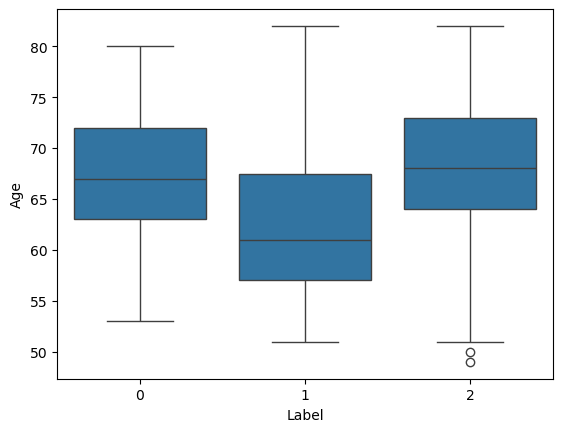

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

# Summary stats
print(df_filtered.groupby('Label')['Age'].describe())

# Boxplot
sns.boxplot(data=df_filtered, x='Label', y='Age')
plt.show()


## Checking distribution of data after removing some patients in order to remove significant differences

### Age


=== Analyzing 'Age' by 'Label' ===


Label: 0 — Variable: Age
Sample size: 62
Optimization terminated successfully.
         Current function value: 0.000047
         Iterations: 59
         Function evaluations: 112

Sample moments:  (66.98387096774194, 45.24167533818938, 0.006504805955110561, 2.3689472010738486)
Fitted moments:  (66.98387096774194, 45.24167533818939, 0.006497329822341838, 2.3689006454846355)

Parameters:  [66.96921282962452, 0.17028240267108577, 0.31919738367387607, 0.31486785650859084]

Goodness-of-Fit
KstestResult(statistic=0.08711263315190709, pvalue=0.7015796998327015, statistic_location=69, statistic_sign=1)
Power_divergenceResult(statistic=8.70967741935484, pvalue=0.27417747416584237)
Shapiro-Wilk test: W=0.9781, p-value=0.3327
Probably Gaussian (normal distribution)

Label: 2 — Variable: Age
Sample size: 57
Optimization terminated successfully.
         Current function value: 0.000058
         Iterations: 71
         Function evaluations: 138

Sample moments

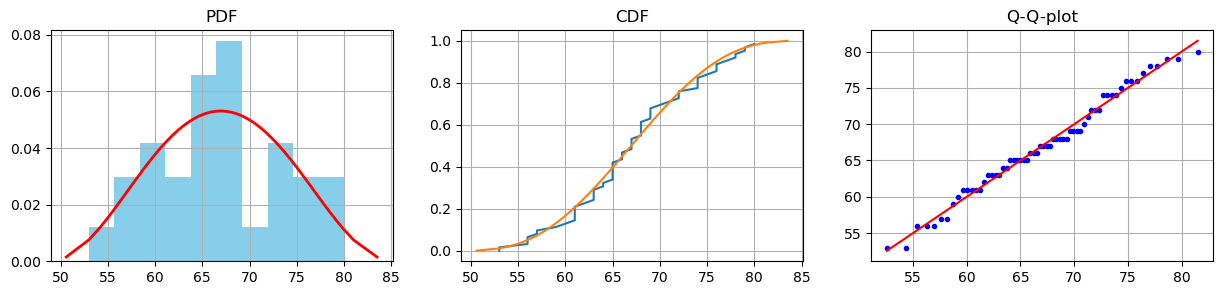

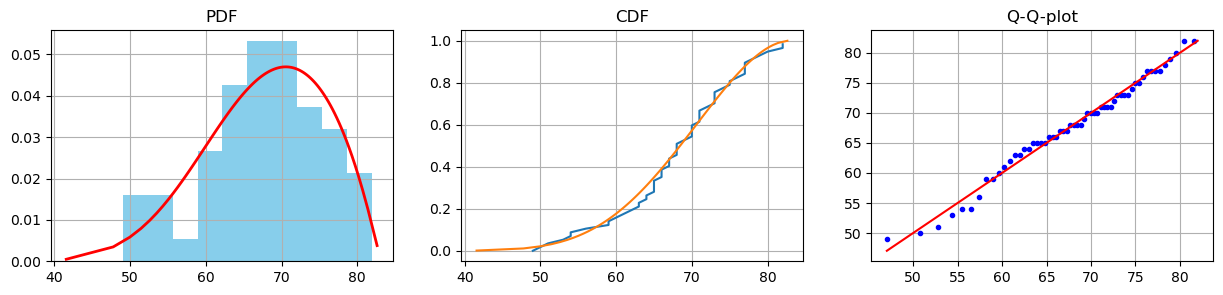

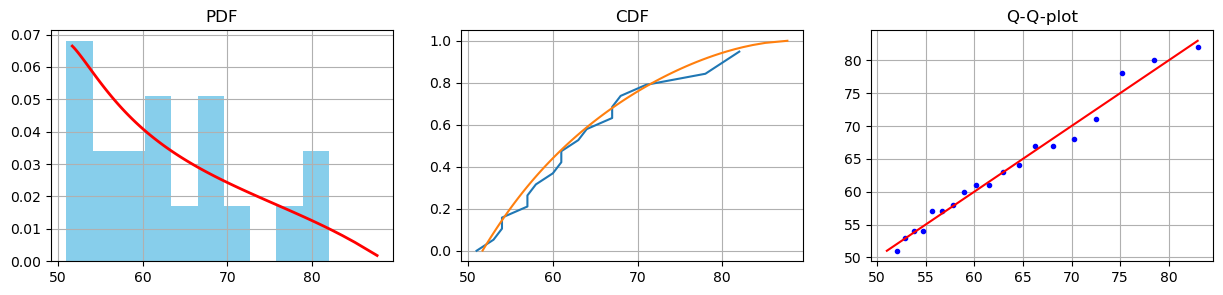

In [51]:
# Example usage:
analyze_distribution_by_label(df_filtered, column='Age', bins_hist = 10)

### Years education


=== Analyzing 'Years_education' by 'Label' ===


Label: 0 — Variable: Years_education
Sample size: 24


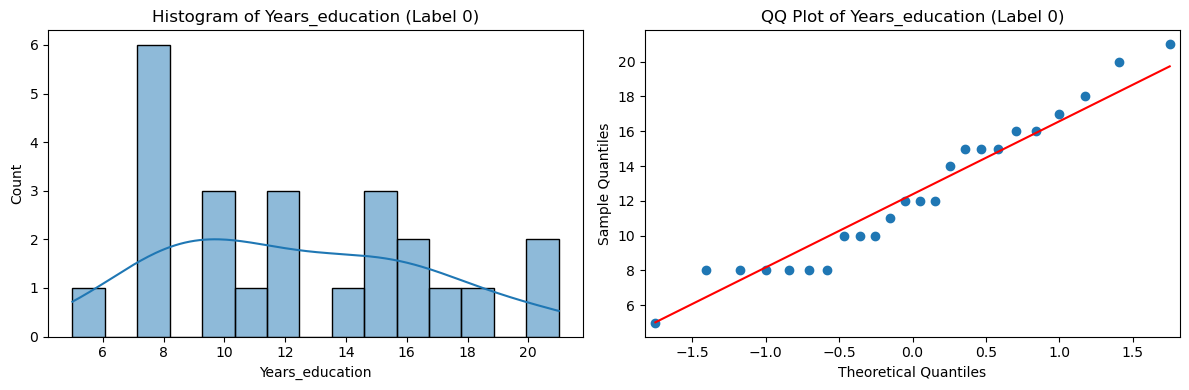

Shapiro-Wilk test: W=0.9489, p-value=0.2559
Probably Gaussian (normal distribution)

Label: 1 — Variable: Years_education
Sample size: 23


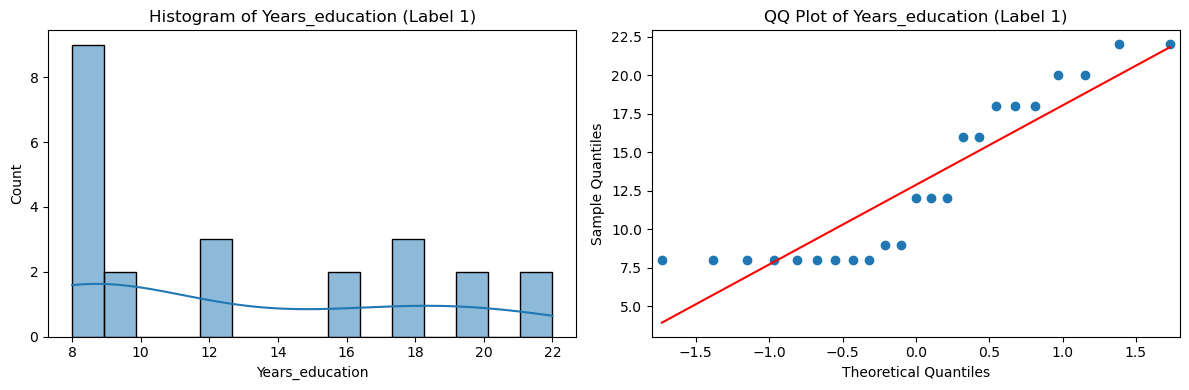

Shapiro-Wilk test: W=0.8160, p-value=0.0007
Probably NOT Gaussian

Label: 2 — Variable: Years_education
Sample size: 28


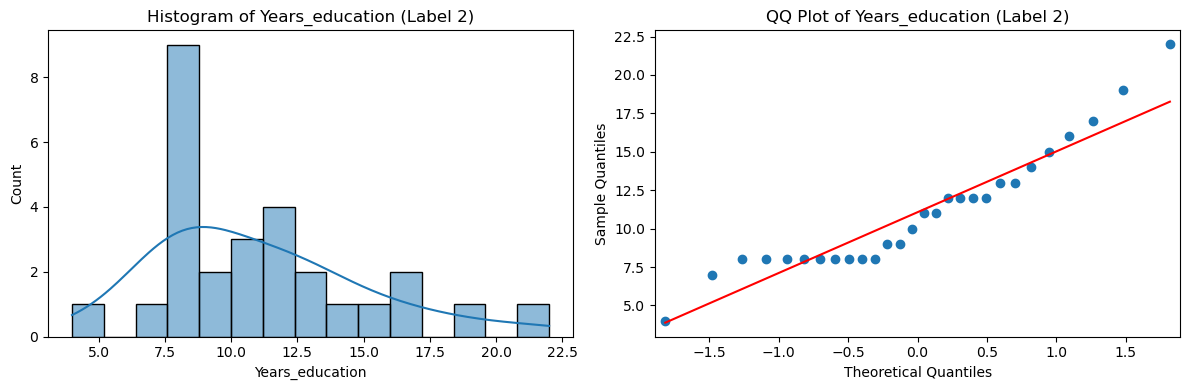

Shapiro-Wilk test: W=0.9138, p-value=0.0245
Probably NOT Gaussian

Label: 3 — Variable: Years_education
Sample size: 32


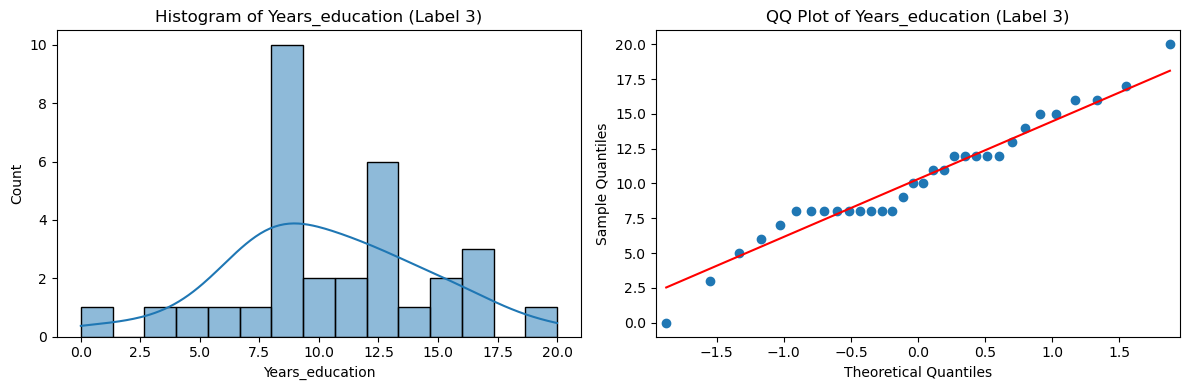

Shapiro-Wilk test: W=0.9722, p-value=0.5617
Probably Gaussian (normal distribution)


In [ ]:
analyze_distribution_by_label(df_filtered, column='Years_education')

### Sex

In [52]:
sex_contigency_filtered_data = chi_squared_vs_label(df_filtered)


Contingency Table (Label × Sex):

       Male (0)  Female (1)
Label                      
0            27          35
1             7          12
2            28          29

Chi-squared Test Results:
Chi2 statistic = 0.9551
Degrees of freedom = 2
p-value = 0.6203

No significant association between Sex and Label


### Age


ANOVA Table for 'Age' across labels [0, 1, 2]:
               sum_sq     df         F   PR(>F)
C(Label)   258.668303    2.0  2.199103  0.11486
Residual  7939.650538  135.0       NaN      NaN

Levene's test for equal variances:
Levene statistic: 1.0875
p-value: 0.3400
Variances are approximately equal (homoscedasticity).

Residual analysis for ANOVA assumptions:


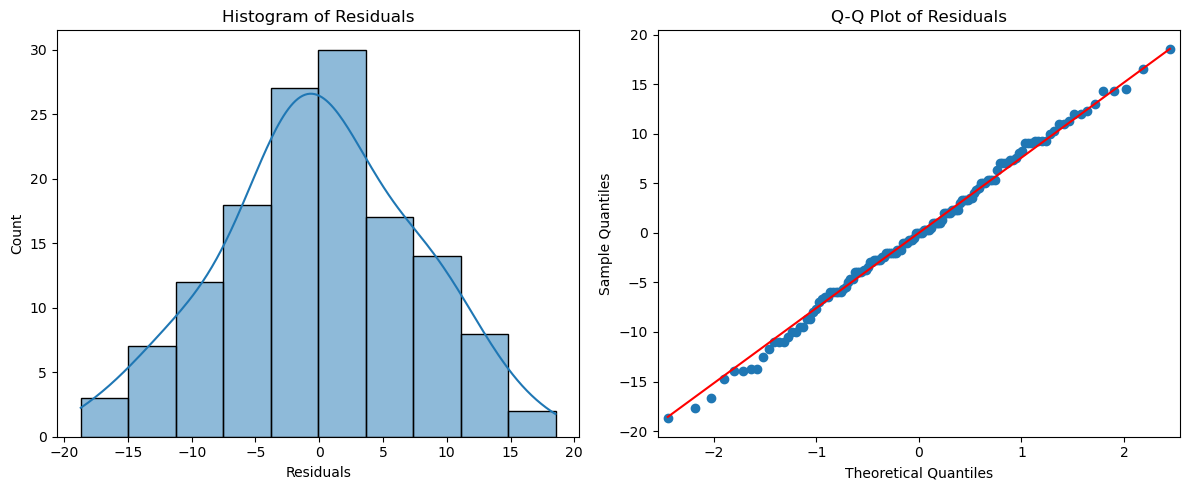

In [53]:
test_by_label(df_filtered, column='Age', label_col='Label', test = 'anova')

In [54]:
result = pairwise_test(df_filtered, label_col = 'Label', column='Age', test='mannwhitney', correction='bonferroni')
print(result)

   Group1  Group2       U     p_raw  p_levene  effect_size  p_adjusted
0       0       2  1608.0  0.398631  0.301536     0.089983    1.000000
1       0       1   759.0  0.058515  0.161296    -0.288625    0.175545
2       2       1   710.5  0.043051  0.548766    -0.312096    0.129154


### Years of education

In [ ]:
test_by_label(df_filtered, column='Years_education')


Kruskal-Wallis test for 'Years_education' across labels [0, 1, 2, 3]:
Test statistic: 3.8436
p-value: 0.2789
No significant differences between groups.


# Analysis metadata 3 groups (HC and NFC as Label 0)

In [59]:
# Replace labels 1 with 0
df_3_groups = df.copy()
df_3_groups['Label'] = df_3_groups['Label'].replace({1: 0})

# no DaTSCAN: ['HUMV_AC_2','HUMV_AC_5', 'HUMV_AC_7','HUMV_AC_8','HUMV_AC_13','HUMV_AC_14','HUMV_AC_15', 'HUMV_AC_16', 'HUMV_AC_26','HUMV_AC_27','HUMV_AC_28','HUMV_AC_29', 'HUMV_AC_31']
# negative datscan: "HUMV_AC_1", "HUMV_AC_3", "HUMV_AC_25", "HUMV_AC_33"


# Now labels 0 and 1 are merged into 0
print(df_3_groups['Label'].value_counts())

Label
0    50
2    34
3    34
Name: count, dtype: int64


Given these age differences, we decided to remove specific patients with ages that contribute to this imbalance in order to homogenize the groups for subsequent analyses.

The following patients will be removed:

- HUMV_HC_4: Age = 39
- HUMV_HC_9: Age = 82
- HUMV_HC_25: Age = 83
- HUMV_NFC_1: Age = 81
- HUMV_NFC_11: Age = 88
- HUMV_NFC_24: Age = 45
- HUMV_AC_24: Age = 48 (with DaTSCAN)
- HUMV_AC_32: Age = 45 (with DaTSCAN)
- HUMV_PD_1: Age = 88
- HUMV_PD_2: Age = 88
- HUMV_PD_9: Age = 84
- HUMV_PD_13: Age = 86

All other patients without DaTScan also will be removed as they are not going to be part of the experiments

In [60]:
# List of patient IDs to remove
# patients_to_remove = ['HUMV_HC_4', 'HUMV_HC_9', 'HUMV_HC_25', 'HUMV_NFC_1', 'HUMV_NFC_11' ,'HUMV_PD_1', 'HUMV_PD_2', 'HUMV_PD_9', 'HUMV_PD_13', 'HUMV_AC_2','HUMV_AC_5', 'HUMV_AC_7','HUMV_AC_8','HUMV_AC_13','HUMV_AC_14','HUMV_AC_15', 'HUMV_AC_16', 'HUMV_AC_24', 'HUMV_AC_26','HUMV_AC_27','HUMV_AC_28','HUMV_AC_29', 'HUMV_AC_31', 'HUMV_AC_32'] # 'HUMV_AC_24','HUMV_AC_32','HUMV_AC_2', 'HUMV_AC_5', 'HUMV_AC_8','HUMV_AC_29'

#patients_to_remove = ['HUMV_HC_4', 'HUMV_AC_2', 'HUMV_AC_5', 'HUMV_AC_8','HUMV_AC_29','HUMV_PD_1', 'HUMV_PD_2'] # DisVoice Study

#patients_to_remove = ['HUMV_HC_3','HUMV_HC_4', 'HUMV_HC_7','HUMV_NFC_2', 'HUMV_NFC_3', 'HUMV_NFC_5','HUMV_NFC_8','HUMV_NFC_9','HUMV_NFC_10','HUMV_NFC_11', 'HUMV_NFC_12', 'HUMV_NFC_13', 'HUMV_NFC_14', 'HUMV_NFC_23', 'HUMV_NFC_24'] # DisVoice Study

patients_to_remove = ['HUMV_HC_1','HUMV_HC_3','HUMV_HC_4', 'HUMV_HC_5','HUMV_HC_6','HUMV_HC_7', 'HUMV_HC_8', 'HUMV_HC_9', 'HUMV_HC_11', 'HUMV_HC_13','HUMV_HC_14','HUMV_HC_15', 'HUMV_HC_16', 'HUMV_HC_17','HUMV_HC_20', 'HUMV_HC_24','HUMV_HC_25', 'HUMV_HC_26', 'HUMV_NFC_1', 'HUMV_NFC_3', 'HUMV_NFC_4', 'HUMV_NFC_6','HUMV_NFC_10','HUMV_NFC_11', 'HUMV_NFC_12', 'HUMV_NFC_13', 'HUMV_NFC_15', 'HUMV_NFC_17', 'HUMV_NFC_23', 'HUMV_NFC_24', 'HUMV_AC_2','HUMV_AC_5', 'HUMV_AC_7','HUMV_AC_8','HUMV_AC_13','HUMV_AC_14','HUMV_AC_15', 'HUMV_AC_16', 'HUMV_AC_26','HUMV_AC_27','HUMV_AC_28','HUMV_AC_29', 'HUMV_AC_31', "HUMV_AC_1", "HUMV_AC_3", "HUMV_AC_25", "HUMV_AC_33"] # Eliminando AC sin DaTSCAN y negativos y DatSCAN negativos


# no DaTSCAN: ['HUMV_AC_2','HUMV_AC_5', 'HUMV_AC_7','HUMV_AC_8','HUMV_AC_13','HUMV_AC_14','HUMV_AC_15', 'HUMV_AC_16', 'HUMV_AC_26','HUMV_AC_27','HUMV_AC_28','HUMV_AC_29', 'HUMV_AC_31']


# Remove duplicates just in case
patients_to_remove = list(set(patients_to_remove))

# Filter the dataframe
df_3_groups = df_3_groups[~df_3_groups['ID'].isin(patients_to_remove)].copy()

       count       mean        std   min    25%   50%   75%   max
Label                                                            
0       20.0  61.800000   4.212763  53.0  60.50  63.0  65.0  67.0
2       17.0  61.058824   9.743399  45.0  54.00  61.0  67.0  80.0
3       34.0  69.500000  10.506131  49.0  63.25  68.0  77.0  88.0


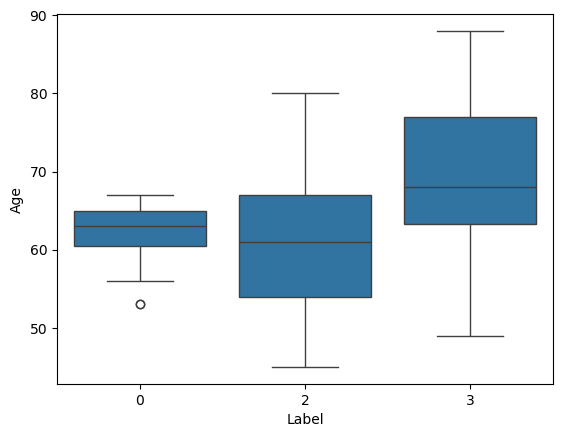

In [61]:
# Summary stats
print(df_3_groups.groupby('Label')['Age'].describe())

# Boxplot
sns.boxplot(data=df_3_groups, x='Label', y='Age')
plt.show()

## Checking distribution of data

### Age


=== Analyzing 'Age' by 'Label' ===

n: 20 finite: 20
min/max: 53 67

Label: 0 — Variable: Age
Sample size: 20
Optimization terminated successfully.
         Current function value: 0.090105
         Iterations: 231
         Function evaluations: 414

Sample moments:  (np.float64(61.8), np.float64(16.860000000000003), np.float64(-0.9010132254440633), np.float64(2.7339488270580805))
Fitted moments:  (np.float64(61.8), np.float64(16.86), np.float64(-0.8109081830398821), np.float64(2.8240538689237145))

Parameters:  [np.float64(64.75437642793888), np.float64(0.15704266883544993), np.float64(0.3809423778804579), np.float64(2.8434927085891517)]
Shapiro-Wilk test: W=0.8859, p-value=0.0226
Probably NOT Gaussian
n: 17 finite: 17
min/max: 45 80

Label: 2 — Variable: Age
Sample size: 17
Optimization terminated successfully.
         Current function value: 0.000032
         Iterations: 63
         Function evaluations: 123

Sample moments:  (np.float64(61.05882352941177), np.float64(89.349480968

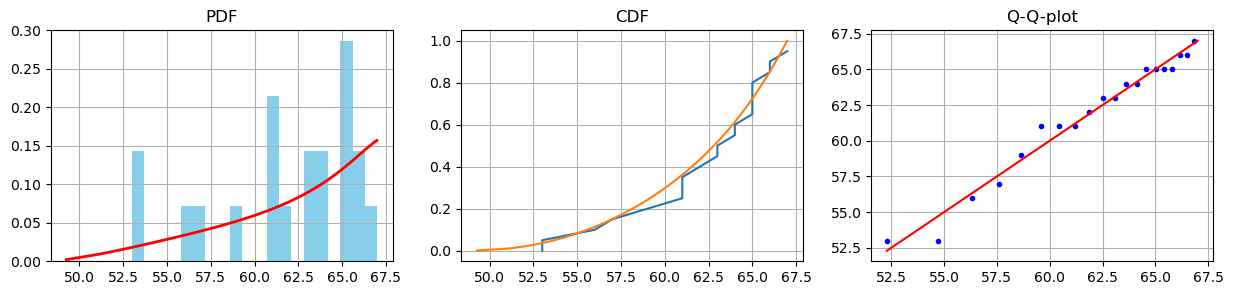

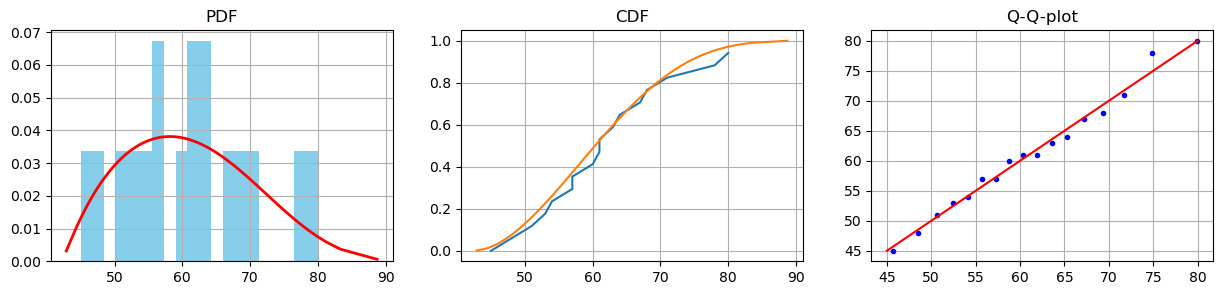

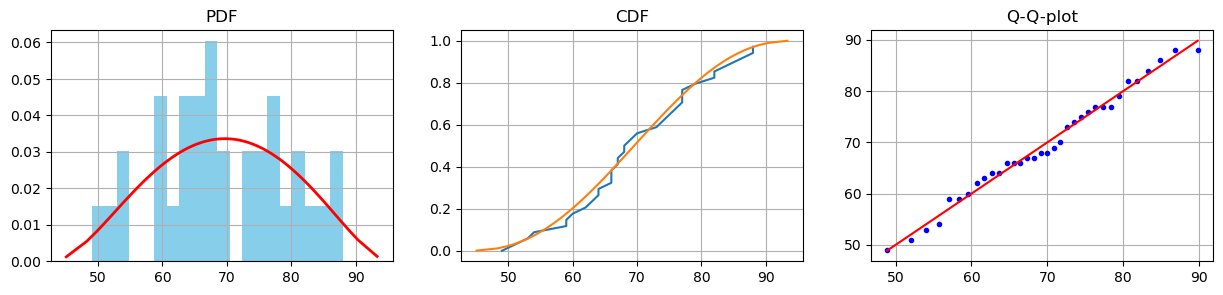

In [62]:
# Example usage:
analyze_distribution_by_label(df_3_groups, column='Age', bins_hist = 20, test_gof=False)

**GLD results analysis example**:

Age Label 0:

**Current function value: 0.000069** -> GLD parameter estimation converged successfully, with minimal error, after 58 iterations

**Function evaluations: 111** -> The fitting algorithm tried 111 function evaluations to match your data's moments with the theoretical GLD's moments.

**Fitted GLD Parameters: [67.555, 0.1434, 0.2235, 0.2175]**

This correspond to:

$\lambda_1$ = 67.56 (location, center)

$\lambda_2$ = 0.1434 (scale)

$\lambda_3$ = 0.2235 (left tail shape)

$\lambda_4$ = 0.2175 (right tail shape)


**statistic = 0.107**
**p-value = 0.605**

Null hypothesis: the data comes from the fitted distribution.

p > 0.05 → we fail to reject the null hypothesis → the GLD fits the data well.

A low KS statistic (0.107) indicates low maximum deviation between the empirical and fitted CDF.

**Chi²-like statistic = 9.33
p-value = 0.23**

Also non-significant (p > 0.05):

The histogram-based test finds no evidence that the GLD is a poor fit.

Confirms the result from the KS test.


### Years education


=== Analyzing 'Years_education' by 'Label' ===

n: 48 finite: 48
min/max: 5.0 22.0

Label: 0 — Variable: Years_education
Sample size: 48
Optimization terminated successfully.
         Current function value: 0.078535
         Iterations: 97
         Function evaluations: 180

Sample moments:  (np.float64(12.729166666666666), np.float64(22.239149305555557), np.float64(0.41304233083908803), np.float64(1.8620814103903347))
Fitted moments:  (np.float64(12.729166666666666), np.float64(22.23914930555556), np.float64(0.3345076037295113), np.float64(1.9406161362313594))

Parameters:  [np.float64(10.524351597786245), np.float64(0.10206949291877931), np.float64(2.068787019701102), np.float64(0.8151916842939366)]
Shapiro-Wilk test: W=0.8964, p-value=0.0005
Probably NOT Gaussian
n: 30 finite: 30
min/max: 4.0 22.0

Label: 2 — Variable: Years_education
Sample size: 30
Optimization terminated successfully.
         Current function value: 0.000010
         Iterations: 55
         Function evaluation

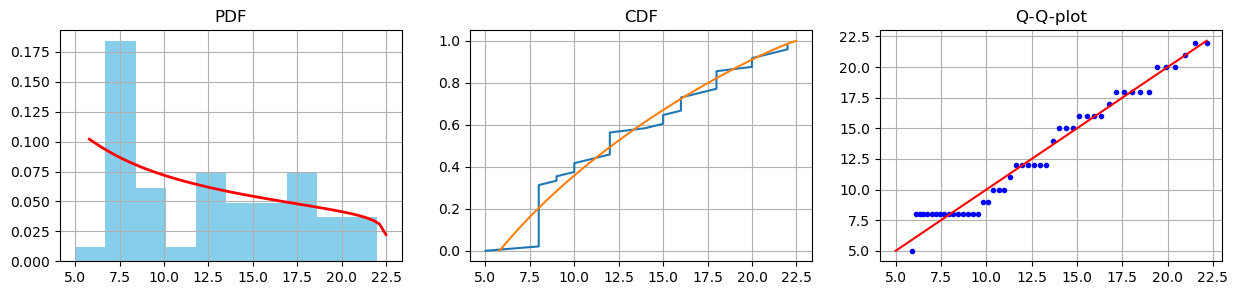

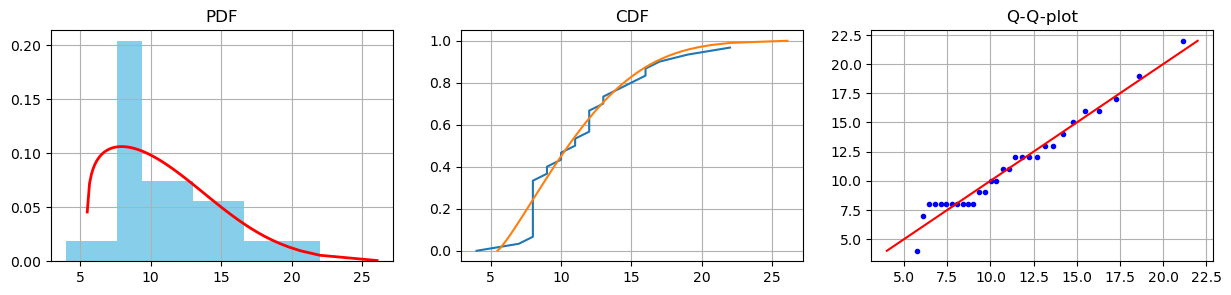

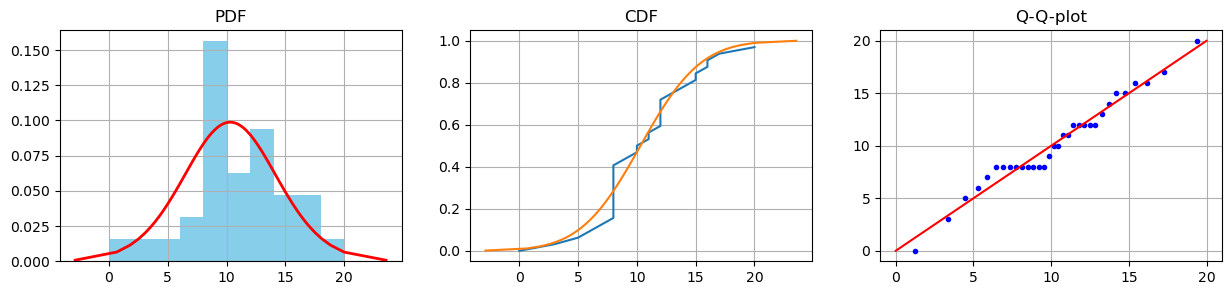

In [41]:
analyze_distribution_by_label(df_3_groups, column='Years_education', bins_hist= 10, test_gof=False )

## Statistical test

### Sex

In [56]:
sex_contigency_filtered_data = chi_squared_vs_label(df_3_groups)


Contingency Table (Label × Sex):

       Male (0)  Female (1)
Label                      
0             9          16
2             7          10
3            12          22

Chi-squared Test Results:
Chi2 statistic = 0.1799
Degrees of freedom = 2
p-value = 0.9140

No significant association between Sex and Label


### Age

In [63]:
test_by_label(df_3_groups, column='Age', label_col='Label', test = 'kruskal')


Kruskal-Wallis test for 'Age' across labels [0, 2, 3]:
Test statistic: 11.9746
p-value: 0.0025
Significant differences found between groups.


In [64]:
result = pairwise_test(df_3_groups, label_col = 'Label', column='Age', test='mannwhitney', correction='fdr_bh')
print(result)

   Group1  Group2      U     p_raw  p_levene  effect_size  p_adjusted
0       0       2  190.5  0.541025  0.007623    -0.120588    0.541025
1       0       3  167.5  0.002036  0.000926     0.507353    0.006108
2       2       3  161.5  0.011106  0.598918     0.441176    0.016658


### Years of education

In [29]:
test_by_label(df_3_groups, column='Years_education', label_col='Label', test = 'kruskal')


Kruskal-Wallis test for 'Years_education' across labels [0, 2, 3]:
Test statistic: 3.6491
p-value: 0.1613
No significant differences between groups.
